In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

In [8]:
df = pd.read_csv("../data/raw/datafile (1).csv")

df.columns = [
    "Crop",
    "State",
    "Cultivation_Cost_A2_FL",
    "Cultivation_Cost_C2",
    "Production_Cost",
    "Yield"
]

crop_encoder = LabelEncoder()
state_encoder = LabelEncoder()

df["Crop"] = crop_encoder.fit_transform(df["Crop"])
df["State"] = state_encoder.fit_transform(df["State"])

In [9]:
X = df.drop("Yield", axis=1)
y = df["Yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [10]:
results = pd.DataFrame({
    "Actual Yield": y_test.values,
    "Predicted Yield": y_pred
})

results

,Actual Yield,Predicted Yield
0,8.05,-66.171965
1,23.59,64.790659
2,34.99,160.669546
3,1015.45,726.175440
4,11.98,61.221831
5,1.32,-221.283041
6,4.05,-115.582284
7,3.01,-140.244699
8,32.42,80.269127
9,9.33,63.967884


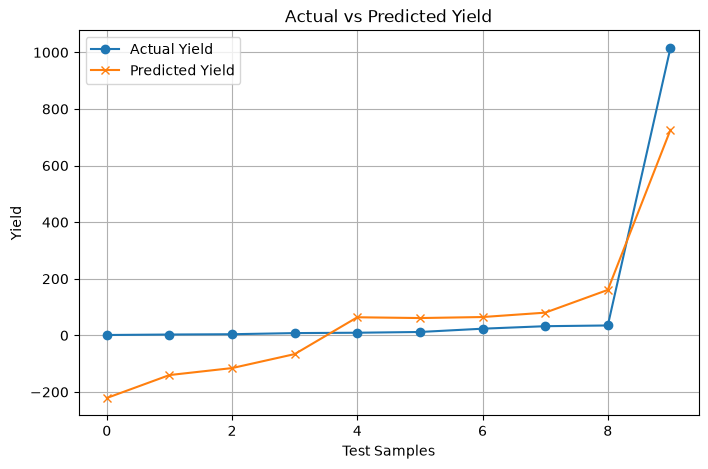

In [11]:
results = results.sort_values(by="Actual Yield").reset_index(drop=True)

plt.figure(figsize=(8,5))

plt.plot(results["Actual Yield"], marker="o", label="Actual Yield")
plt.plot(results["Predicted Yield"], marker="x", label="Predicted Yield")

plt.title("Actual vs Predicted Yield")
plt.xlabel("Test Samples")
plt.ylabel("Yield")

plt.legend()
plt.grid(True)

plt.show()

In [12]:
joblib.dump(model, "../models/crop_yield_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!
